In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tools import load, cpu_boxplot, lineplot

# 

# CPU Times of Algorithm runs

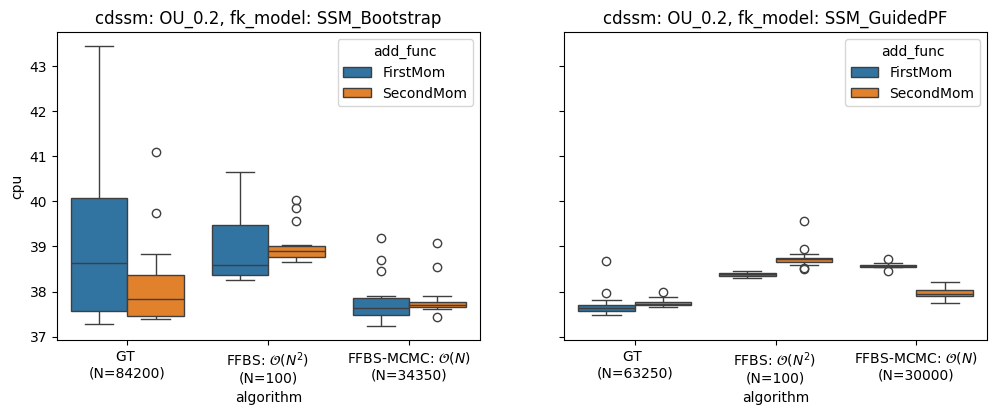

In [3]:
data_6 = load('config_6.json')
data_7 = load('config_7.json')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0] = cpu_boxplot(axes[0], data_6['config'], data_6['smc_wide'], 'OU_0.2', 'SSM_Bootstrap', algorithms=None)
axes[1] = cpu_boxplot(axes[1], data_7['config'], data_7['smc_wide'], 'OU_0.2', 'SSM_GuidedPF', algorithms=None)

plt.show()

In [4]:
def boxplot(ax, cdssm: str, add_func: str, t: int, smc_df: pd.DataFrame, ground_truth_df=None):
    mask = (smc_df['cdssm'] == cdssm) & (smc_df['add_func'] == add_func)
    smc_df_f = smc_df[mask][['algorithm', 'fk', 'N', str(t)]]
    smc_df_f['fk'] = smc_df['fk'].replace({'BsR_DH': 'Bootstrap', 'BootstrapDA': 'Bootstrap'})
    ax = sns.boxplot(data=smc_df_f, x='algorithm', y=str(t), hue='fk', ax=ax)
    x_min, x_max = ax.get_xlim(); x_diff = x_max - x_min
    if ground_truth_df is not None:
        mask = (ground_truth_df['cdssm'] == cdssm) & (ground_truth_df['add_func'] == add_func)
        ground_truth = ground_truth_df[mask][str(t)].iat[0]
        line_2d_kwargs = dict(lw=2.0, ls='--', alpha=0.6, color='black', label='true') 
        ax.hlines(y=ground_truth, xmin=x_min, xmax=x_max, **line_2d_kwargs)
        ax.set(xlim=(x_min, x_max), xlabel='', ylabel='')
    ax.get_legend().remove()
    return ax

# Boxplots of algorithm runs

In [1]:
fig, ax = plt.subplots(1, 1)

smc_df = pd.concat([data_6['smc_wide'], data_6['ground_truth']], axis=0, ignore_index=True)

boxplot(ax, 'OU_0.2', 'FirstMom', 1000, smc_df, data_6['ground_truth'])

NameError: name 'plt' is not defined

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 16,
})

add_func_name = 'FirstMom'
fk_name = 'SSM_Bootstrap'

data = data_6 if fk_name == 'SSM_Bootstrap' else data_7

# T=10000, All Algorithms

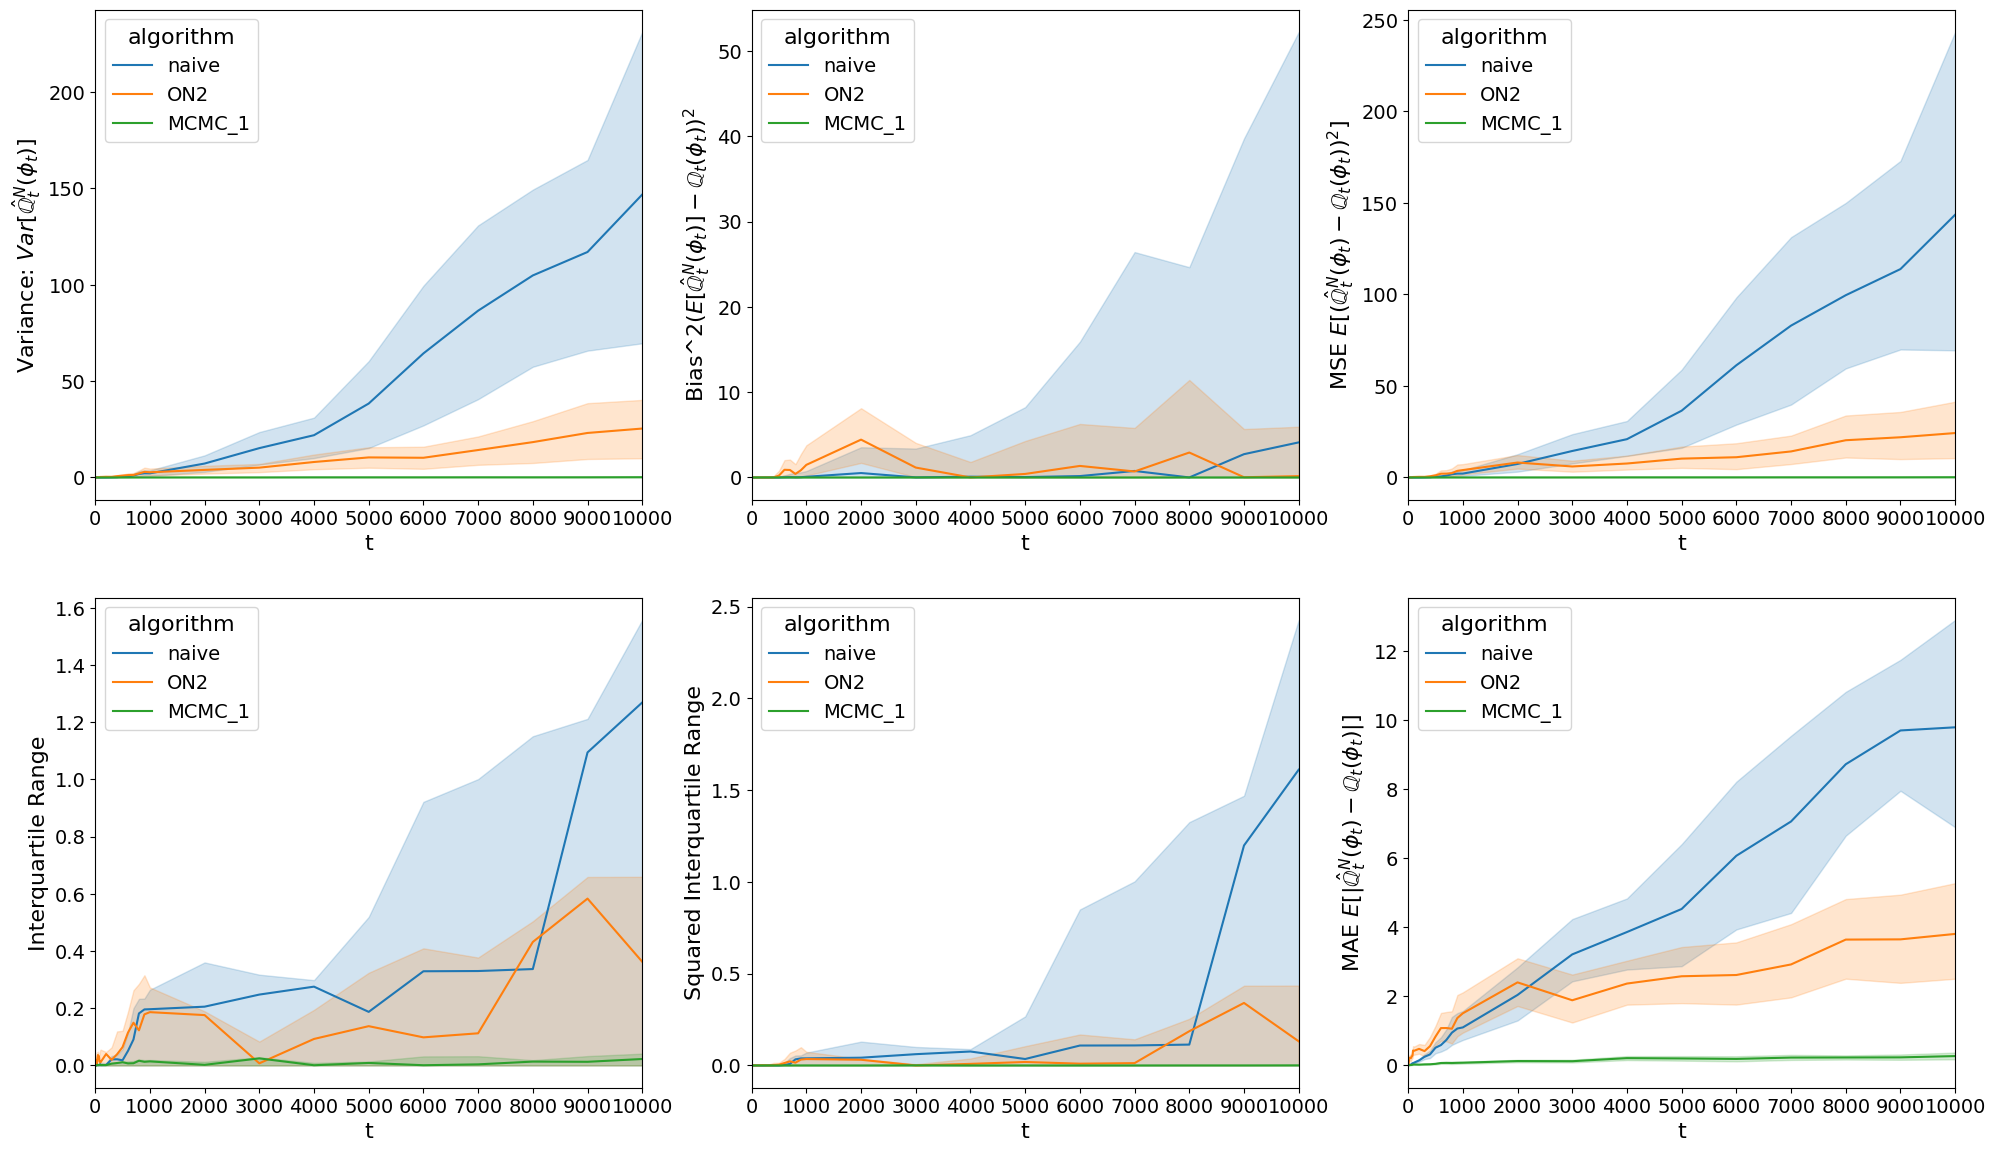

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

estimators = ['variance', 'bias2', 'mse', 'IQR', 'IQR2', 'mae']

for ax, estimator in zip(axes.ravel(), estimators):
    lineplot(ax, data, estimator=estimator, cdssm_name='OU_0.2', add_func_name=add_func_name, fk_name=fk_name, T=10000, algorithms=None)
    ax.set_title('')
plt.show()


# T=10000, $\mathcal{O}(N)$ Algorithms only

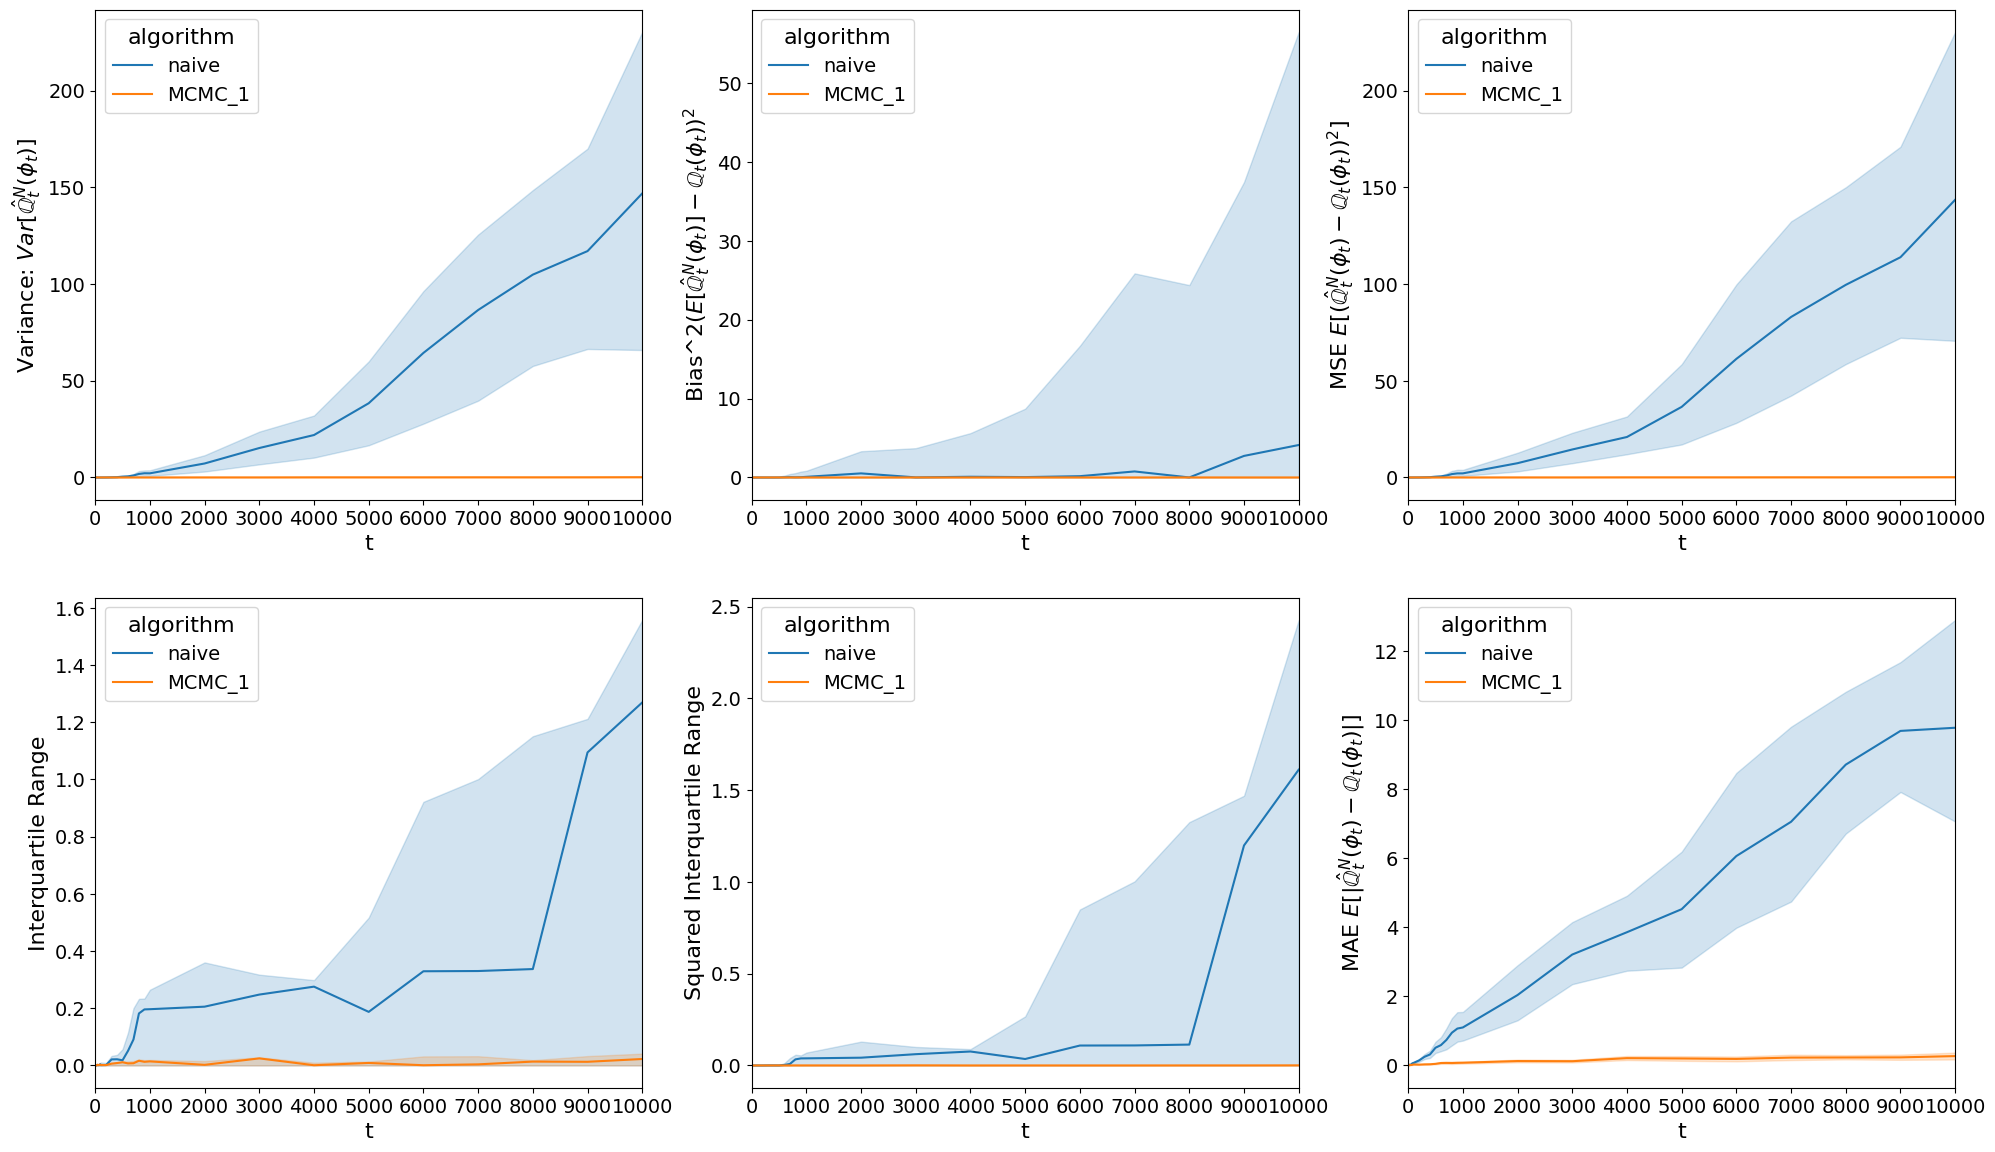

(0.0, 20.0)

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

estimators = ['variance', 'bias2', 'mse', 'IQR', 'IQR2', 'mae']

for ax, estimator in zip(axes.ravel(), estimators):
    lineplot(ax, data, estimator=estimator, cdssm_name='OU_0.2', add_func_name=add_func_name, fk_name=fk_name, T=10000, algorithms=['naive', 'MCMC_1'])
    ax.set_title('')
plt.show()

axes.ravel()[0].set_ylim((0, 20))


# T=1000, All algorithms

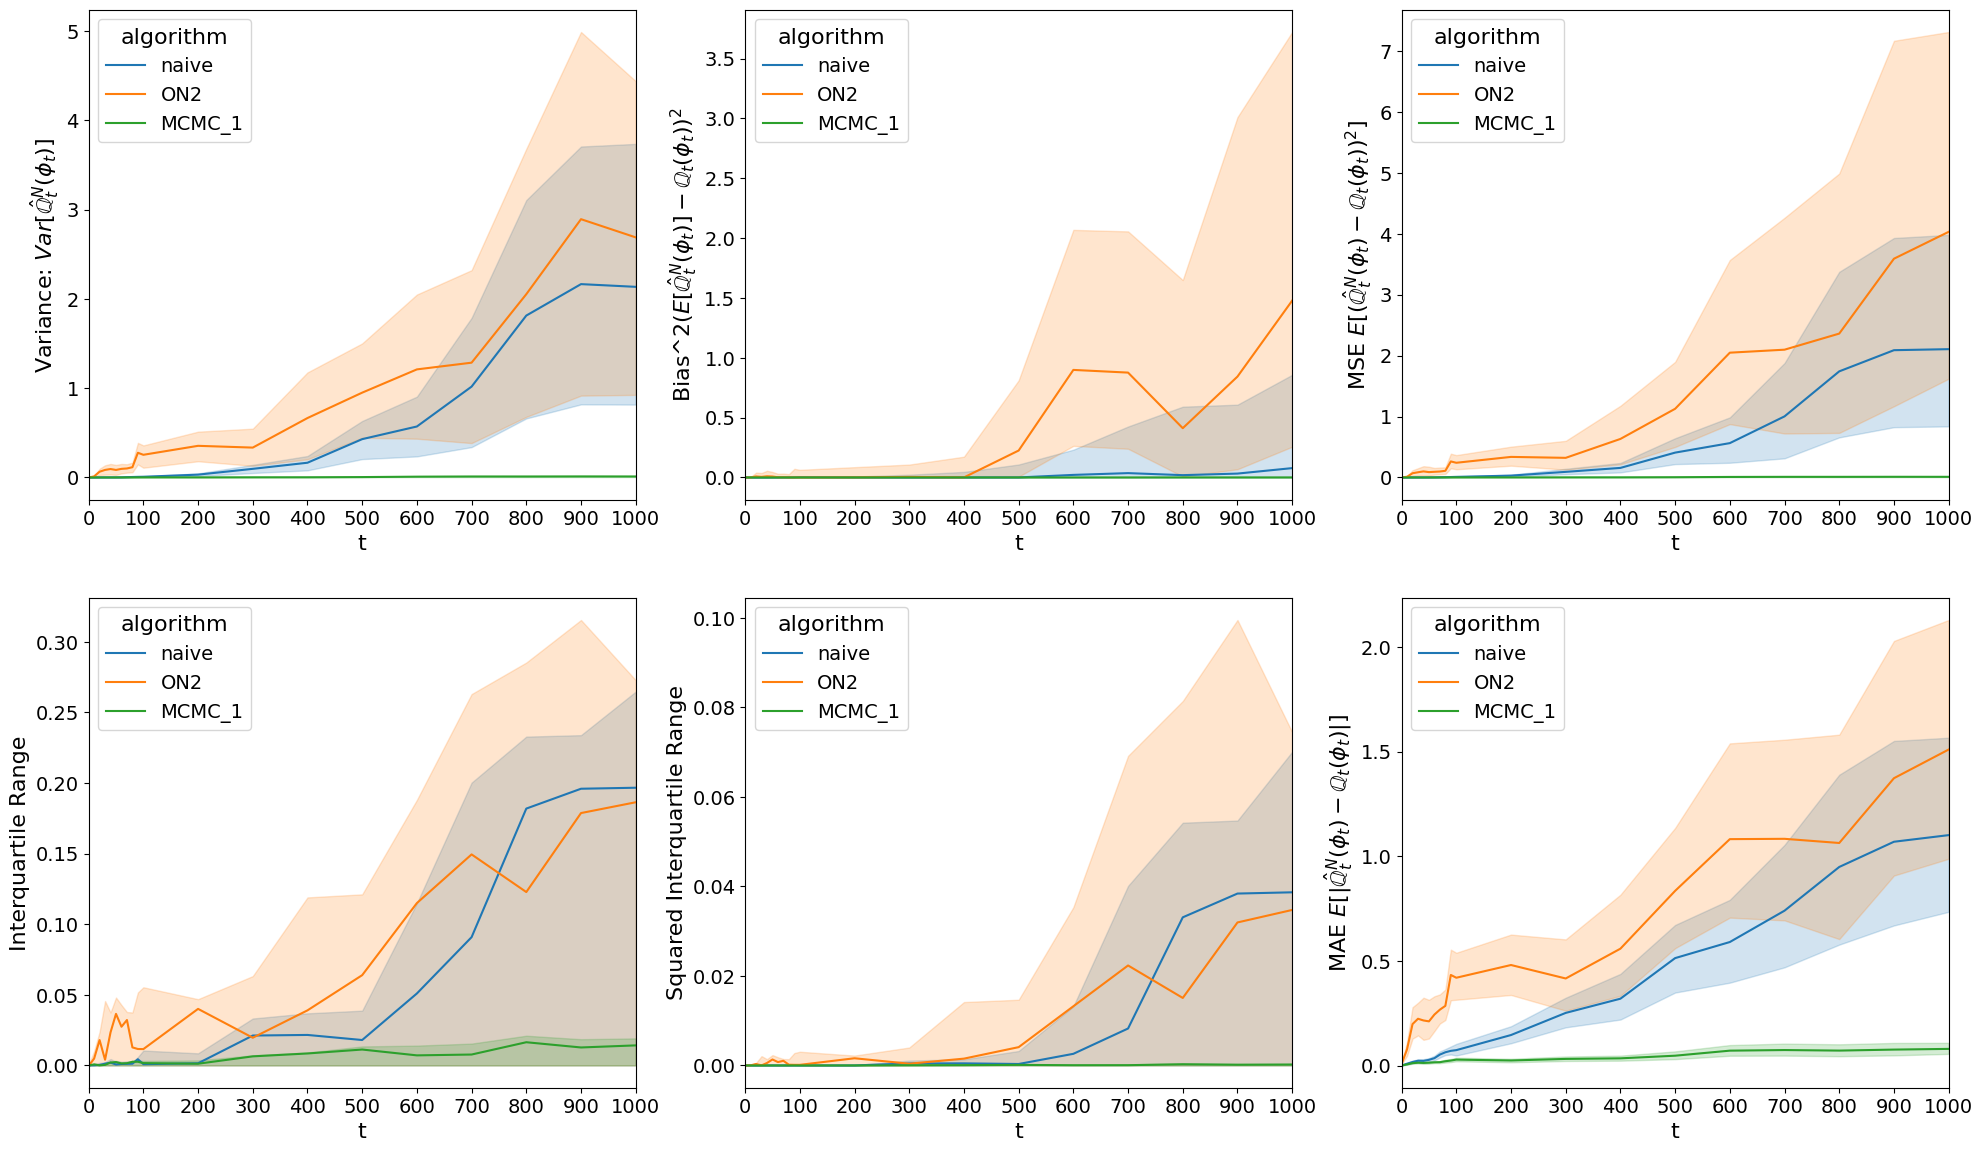

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

estimators = ['variance', 'bias2', 'mse', 'IQR', 'IQR2', 'mae']

for ax, estimator in zip(axes.ravel(), estimators):
    lineplot(ax, data, estimator=estimator, cdssm_name='OU_0.2', add_func_name=add_func_name, fk_name=fk_name, T=1000, algorithms=None)
    ax.set_title('')
plt.show()

# T=1000, $\mathcal{O}(N)$ algorithms only

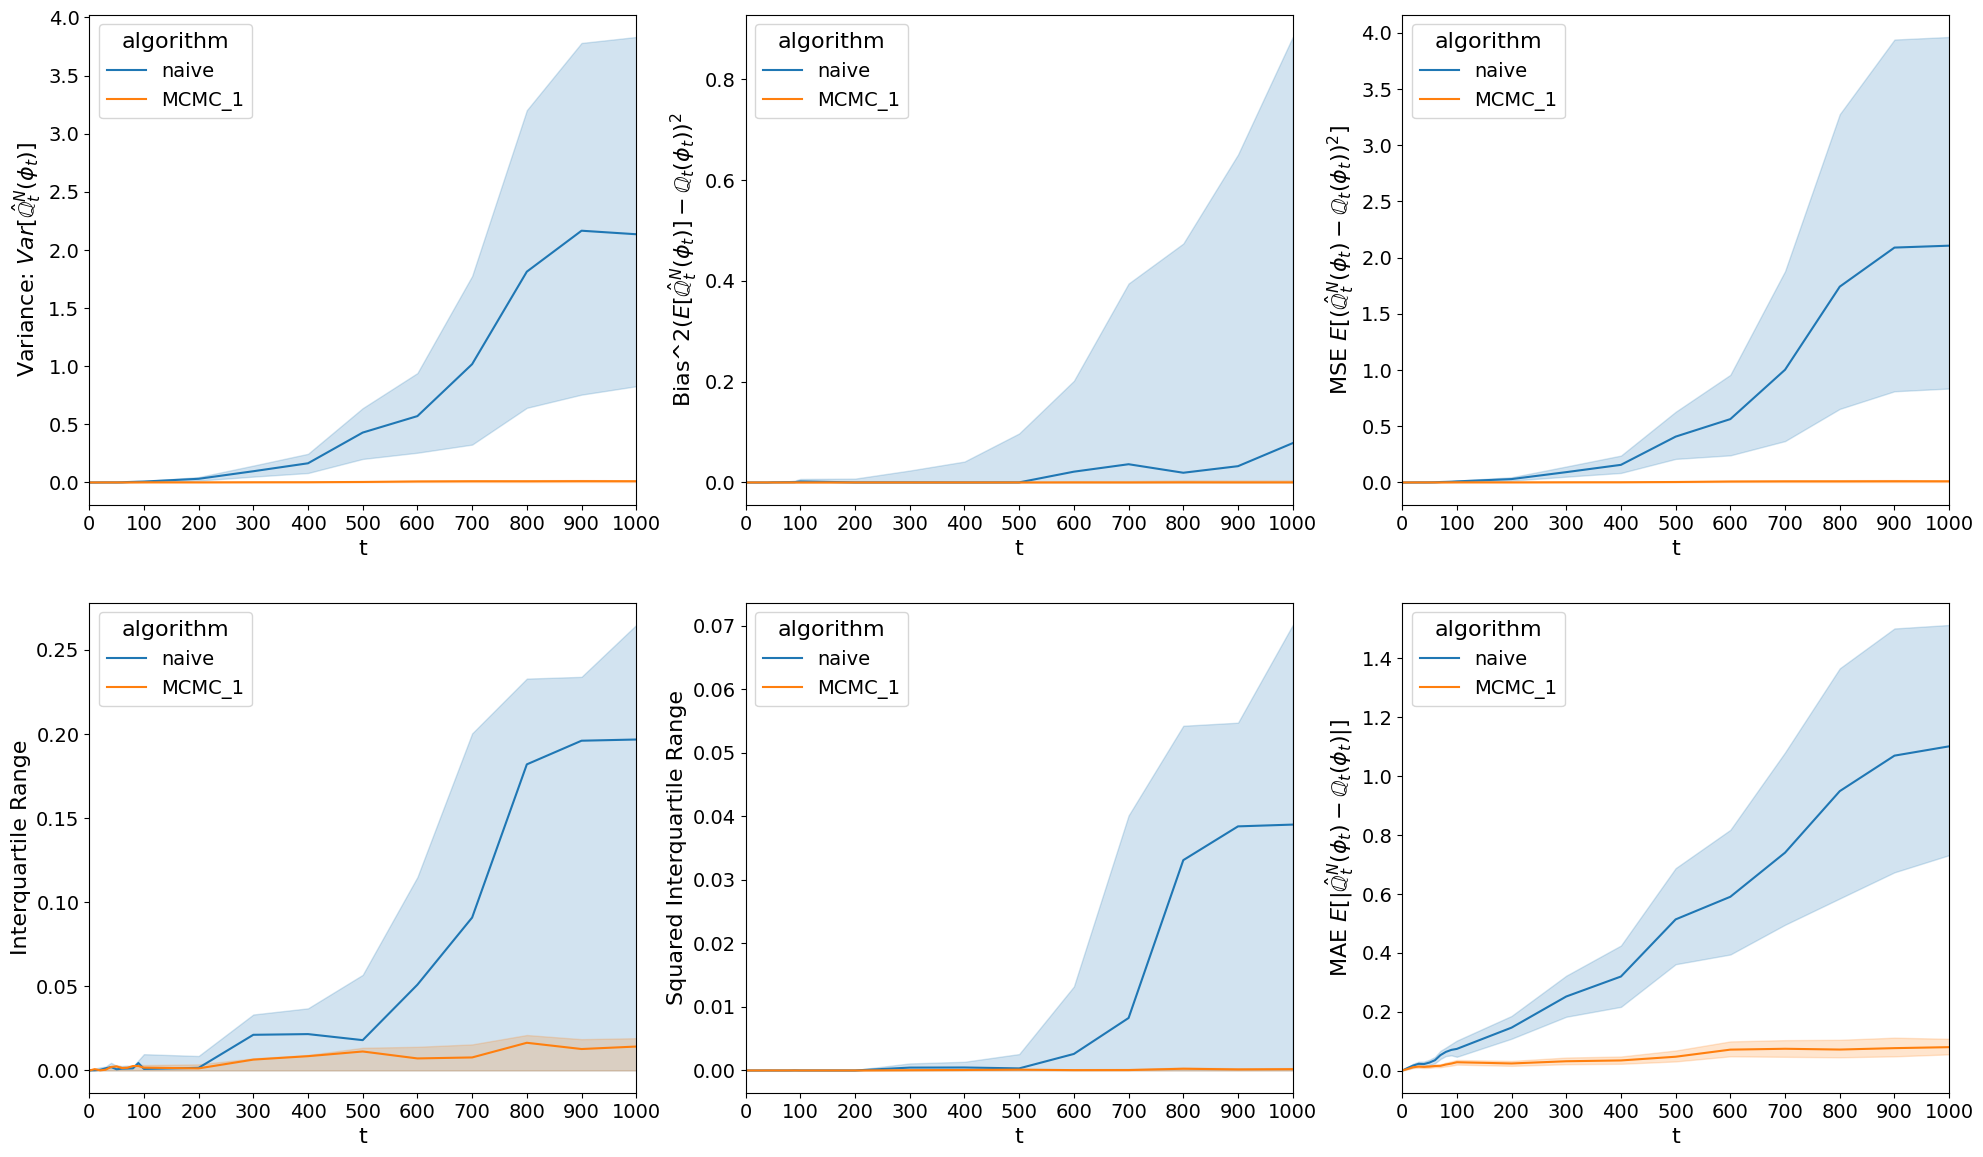

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

estimators = ['variance', 'bias2', 'mse', 'IQR', 'IQR2', 'mae']

for ax, estimator in zip(axes.ravel(), estimators):
    lineplot(ax, data, estimator=estimator, cdssm_name='OU_0.2', add_func_name=add_func_name, fk_name=fk_name, T=1000, algorithms=['naive', 'MCMC_1'])
    ax.set_title('')
plt.show()
